In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
rnadist400 = "./BRONZE/long_run_filter100/rnadist/dist_400/"
rnadist200 = "./BRONZE/long_run_filter100/rnadist/dist_200/"
rnadist100 = "./BRONZE/long_run_filter100/rnadist/dist_100/"
famfold = "./BRONZE/long_run_filter100/famfold/"

fams = ['23s', 'telomerase', '16s', '5s', 'grp1', 'srp', 'RNaseP', 'tmRNA', 'tRNA']
def read_dfs(BASE_PATH):
    epochs = [n*5 for n in range(1,11)]
    dfs = { f: [] for f in fams}

    for f in fams:
        for i,ep in enumerate(epochs):
            path = BASE_PATH + f"{ep}_epoch/" + f"{f}/"
        
            train = pd.read_csv(path+"train_log.csv")
            if i>0:
                train["epoch"] += epochs[i-1] 
            test = pd.read_csv(path + "test.csv") 
            train.loc[train.index[-1], "f1"] = test["f1"].values[0]  
            train.loc[train.index[-1], "f1_post"] = test["f1_post"].values[0]   
            dfs[f].append(train)

        dfs[f] = pd.concat(dfs[f], ignore_index=True)
    return dfs
dfs = read_dfs(rnadist100)

In [32]:
dfs["23s"].head()

,epoch,train_f1,train_loss,valid_f1,valid_f1_post,valid_loss,f1,f1_post
0,0,0.2093,0.0696,0.2916,0.3186,0.0495,NaN,NaN
1,1,0.3364,0.0355,0.3468,0.3790,0.0426,NaN,NaN
2,2,0.3731,0.0320,0.3725,0.4041,0.0407,NaN,NaN
3,3,0.4047,0.0294,0.3973,0.4276,0.0402,NaN,NaN
4,4,0.4244,0.0287,0.4243,0.4557,0.0374,0.392,0.41


/tmp/ipykernel_1261733/3730152107.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


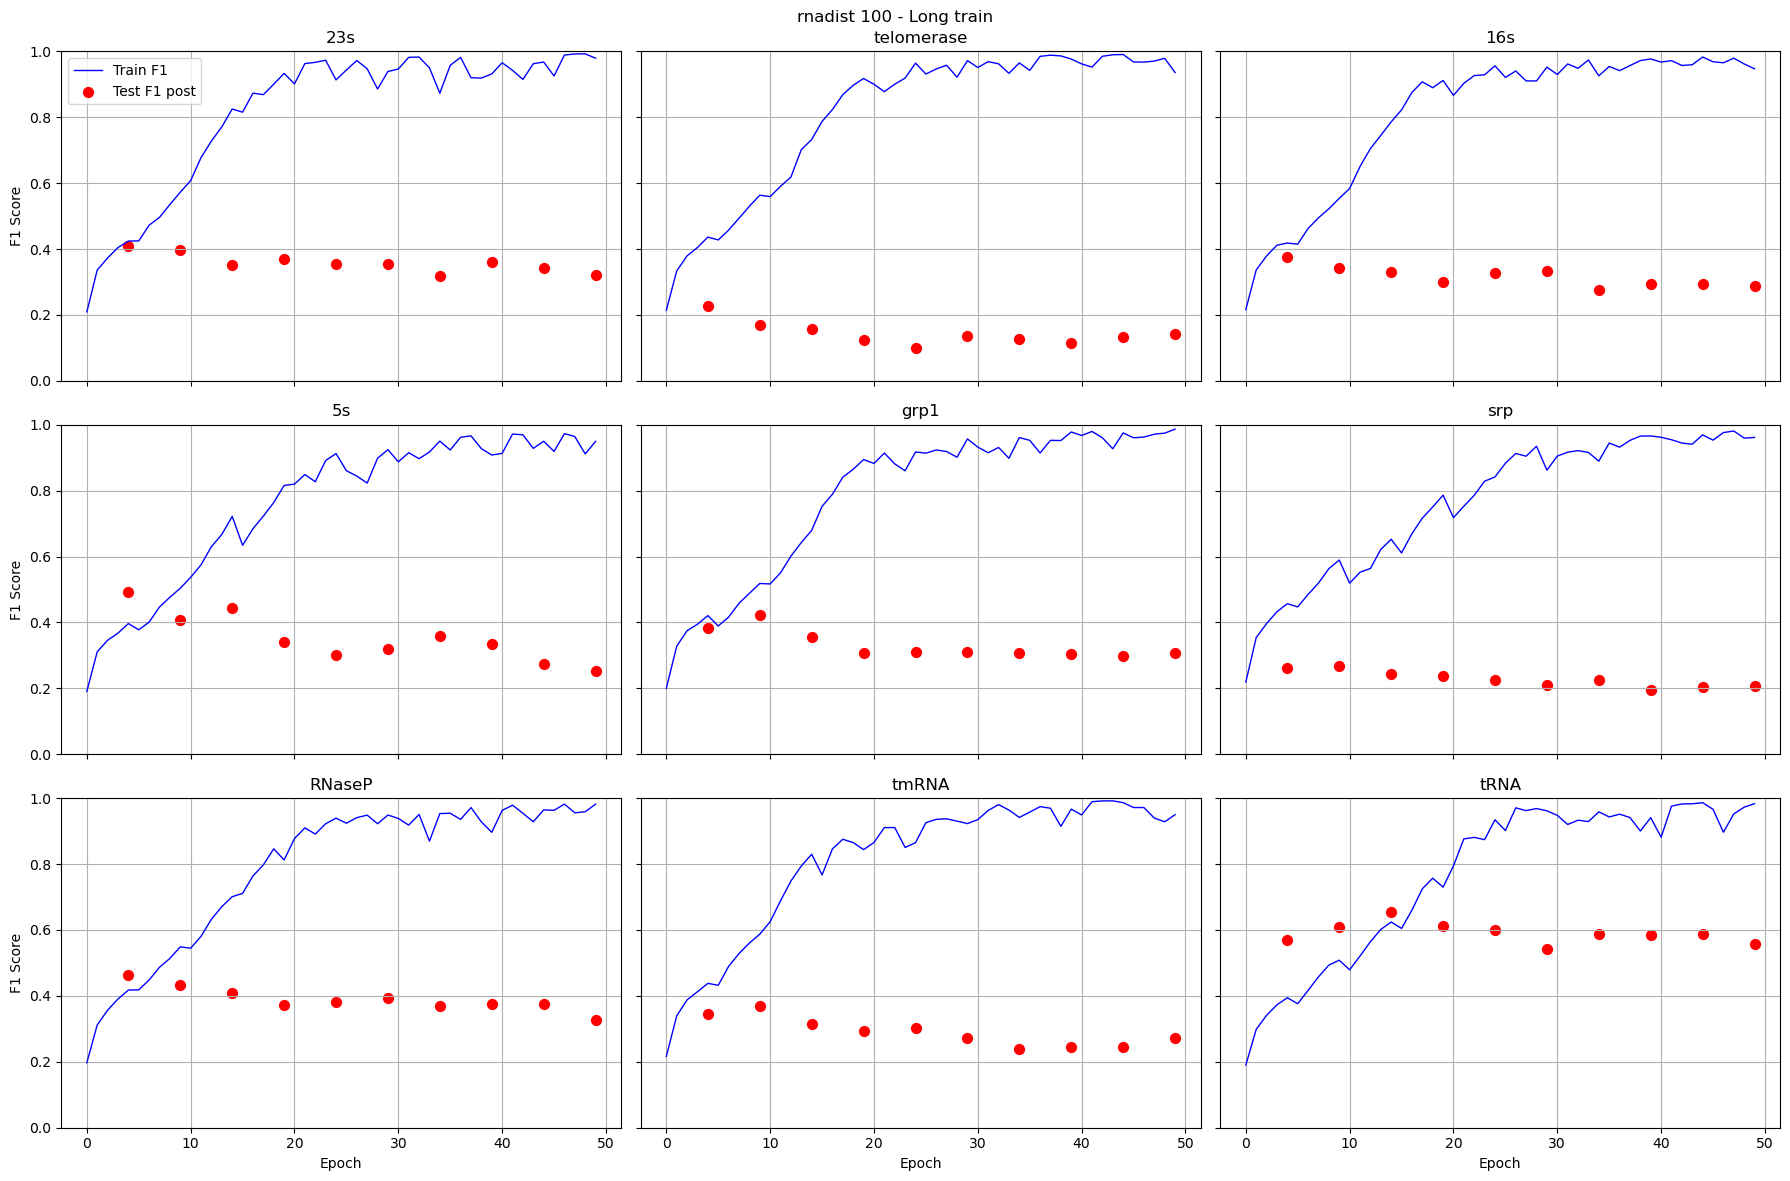

In [33]:
n_fams = len(fams)
cols = 3  # número de columnas en la figura
rows = (n_fams + cols - 1) // cols  # calcular filas necesarias

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()  # para indexar fácilmente

for ax, f in zip(axes, fams):
    df = dfs[f]
    ax.plot(df['epoch'], df['train_f1'], label='Train F1', color='blue', linewidth=1)
    
    # Test F1
    test_rows = df['f1_post'].notna()
    ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
               color='red', s=50, label='Test F1 post')
     
    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)  # uniforme para todas
    ax.grid(True)
for n in [6,7,8]:    
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')
axes[0].legend(loc="upper left")

# Si hay ejes sobrantes (más subplots que familias), los ocultamos
for ax in axes[n_fams:]:
    ax.set_visible(False)
fig.suptitle("rnadist 100 - Long train")
fig.tight_layout()
plt.show()


In [34]:
base = 557+1283+35+462+454+74+15+918+66

n=400
print(base)
for n in [100,200,400]:
    d= n+n+35+n+n+74+15+n+66
    print(d, round(d/base, 3))

3864
690 0.179
1190 0.308
2190 0.567


/tmp/ipykernel_1261733/844422890.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


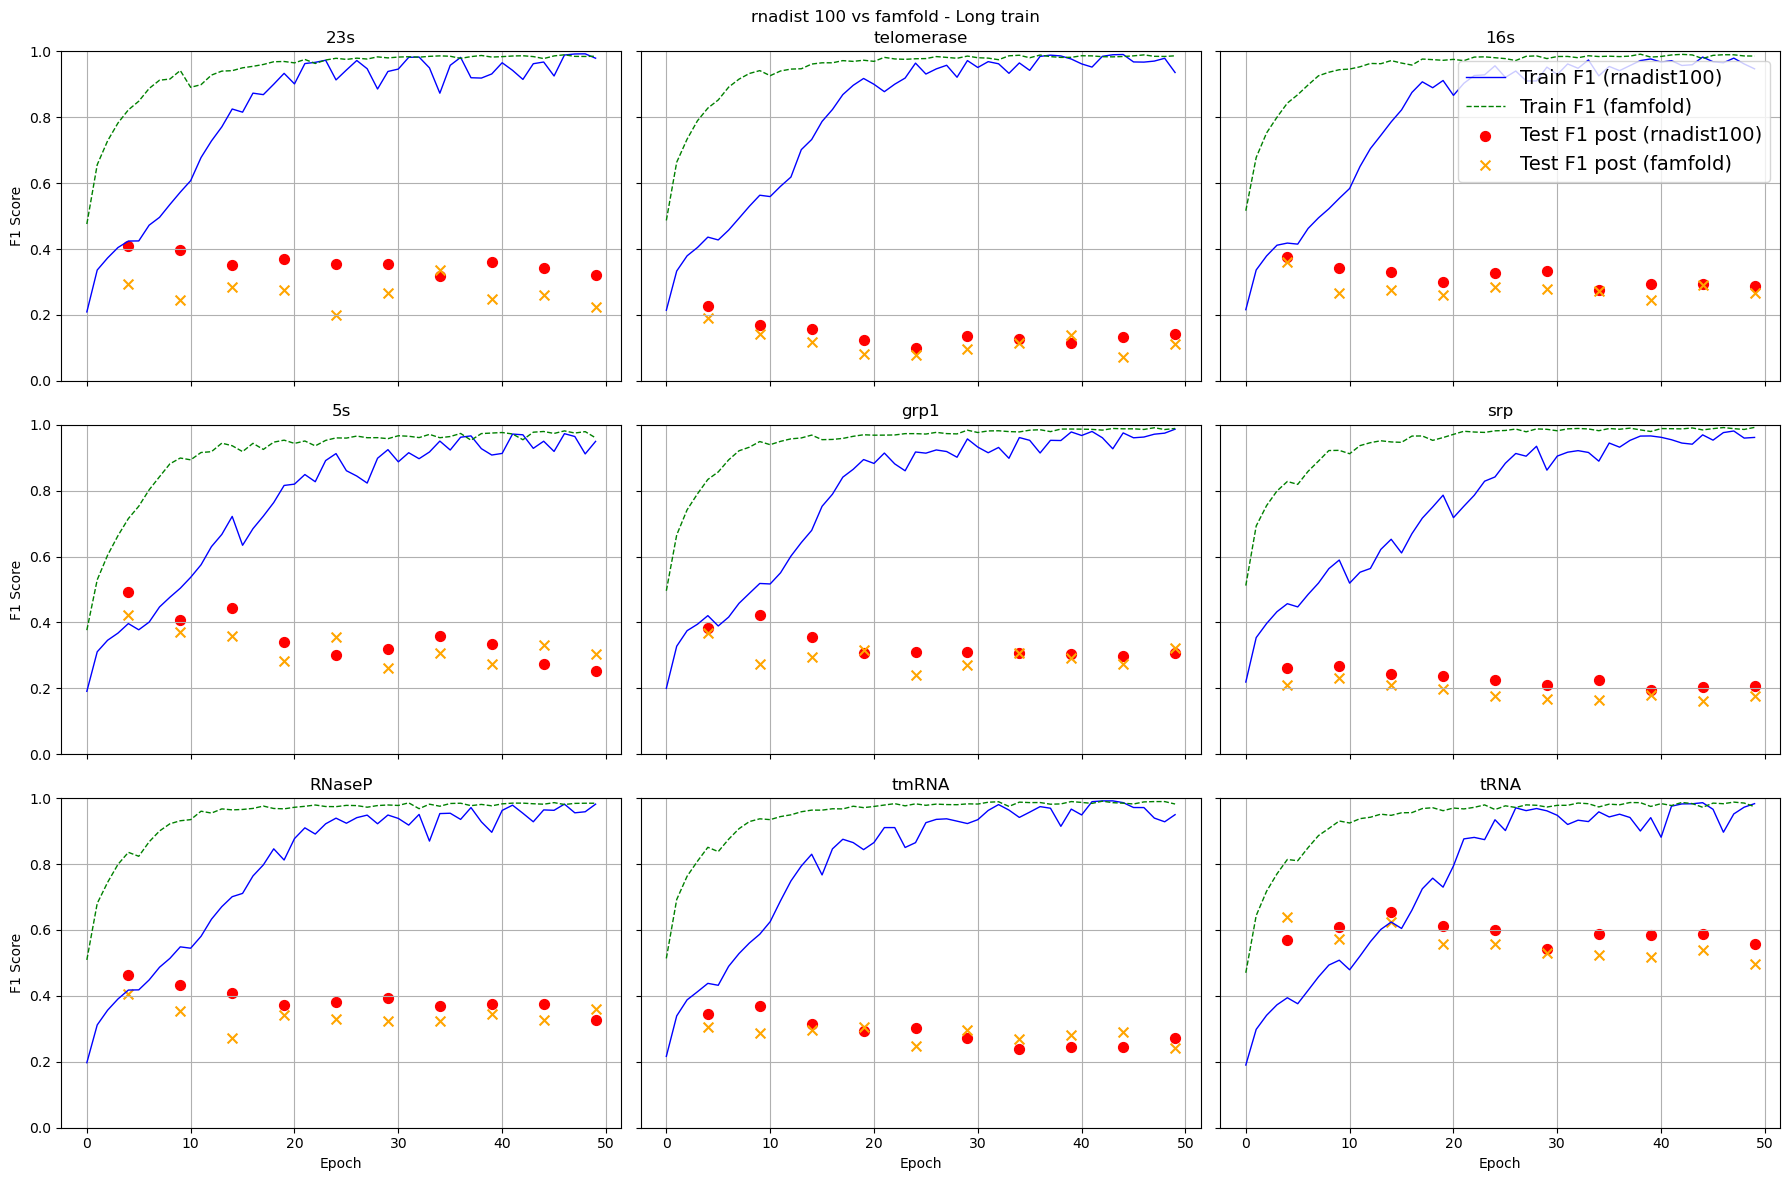

In [35]:
# leer ambos sets
dfs1 = read_dfs(rnadist100)
dfs2 = read_dfs(famfold)

n_fams = len(fams)
cols = 3
rows = (n_fams + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for ax, f in zip(axes, fams):
    df1 = dfs1[f]
    df2 = dfs2[f]

    # Train F1
    ax.plot(df1['epoch'], df1['train_f1'], label='Train F1 (rnadist100)', color='blue', linewidth=1)
    ax.plot(df2['epoch'], df2['train_f1'], label='Train F1 (famfold)',    color='green', linewidth=1, linestyle='--')

    # Test F1 post
    test_rows1 = df1['f1_post'].notna()
    test_rows2 = df2['f1_post'].notna()
    ax.scatter(df1.loc[test_rows1, 'epoch'], df1.loc[test_rows1, 'f1_post'],
               color='red', s=50, label='Test F1 post (rnadist100)')
    ax.scatter(df2.loc[test_rows2, 'epoch'], df2.loc[test_rows2, 'f1_post'],
               color='orange', s=50, marker='x', label='Test F1 post (famfold)')

    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(True)

for n in [6,7,8]:
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')

# legend solo en el primero
axes[2].legend(loc="upper right", fontsize=14)

# ocultar sobrantes
for ax in axes[n_fams:]:
    ax.set_visible(False)

fig.suptitle("rnadist 100 vs famfold - Long train")
fig.tight_layout()
plt.show()


/tmp/ipykernel_1261733/2815523503.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


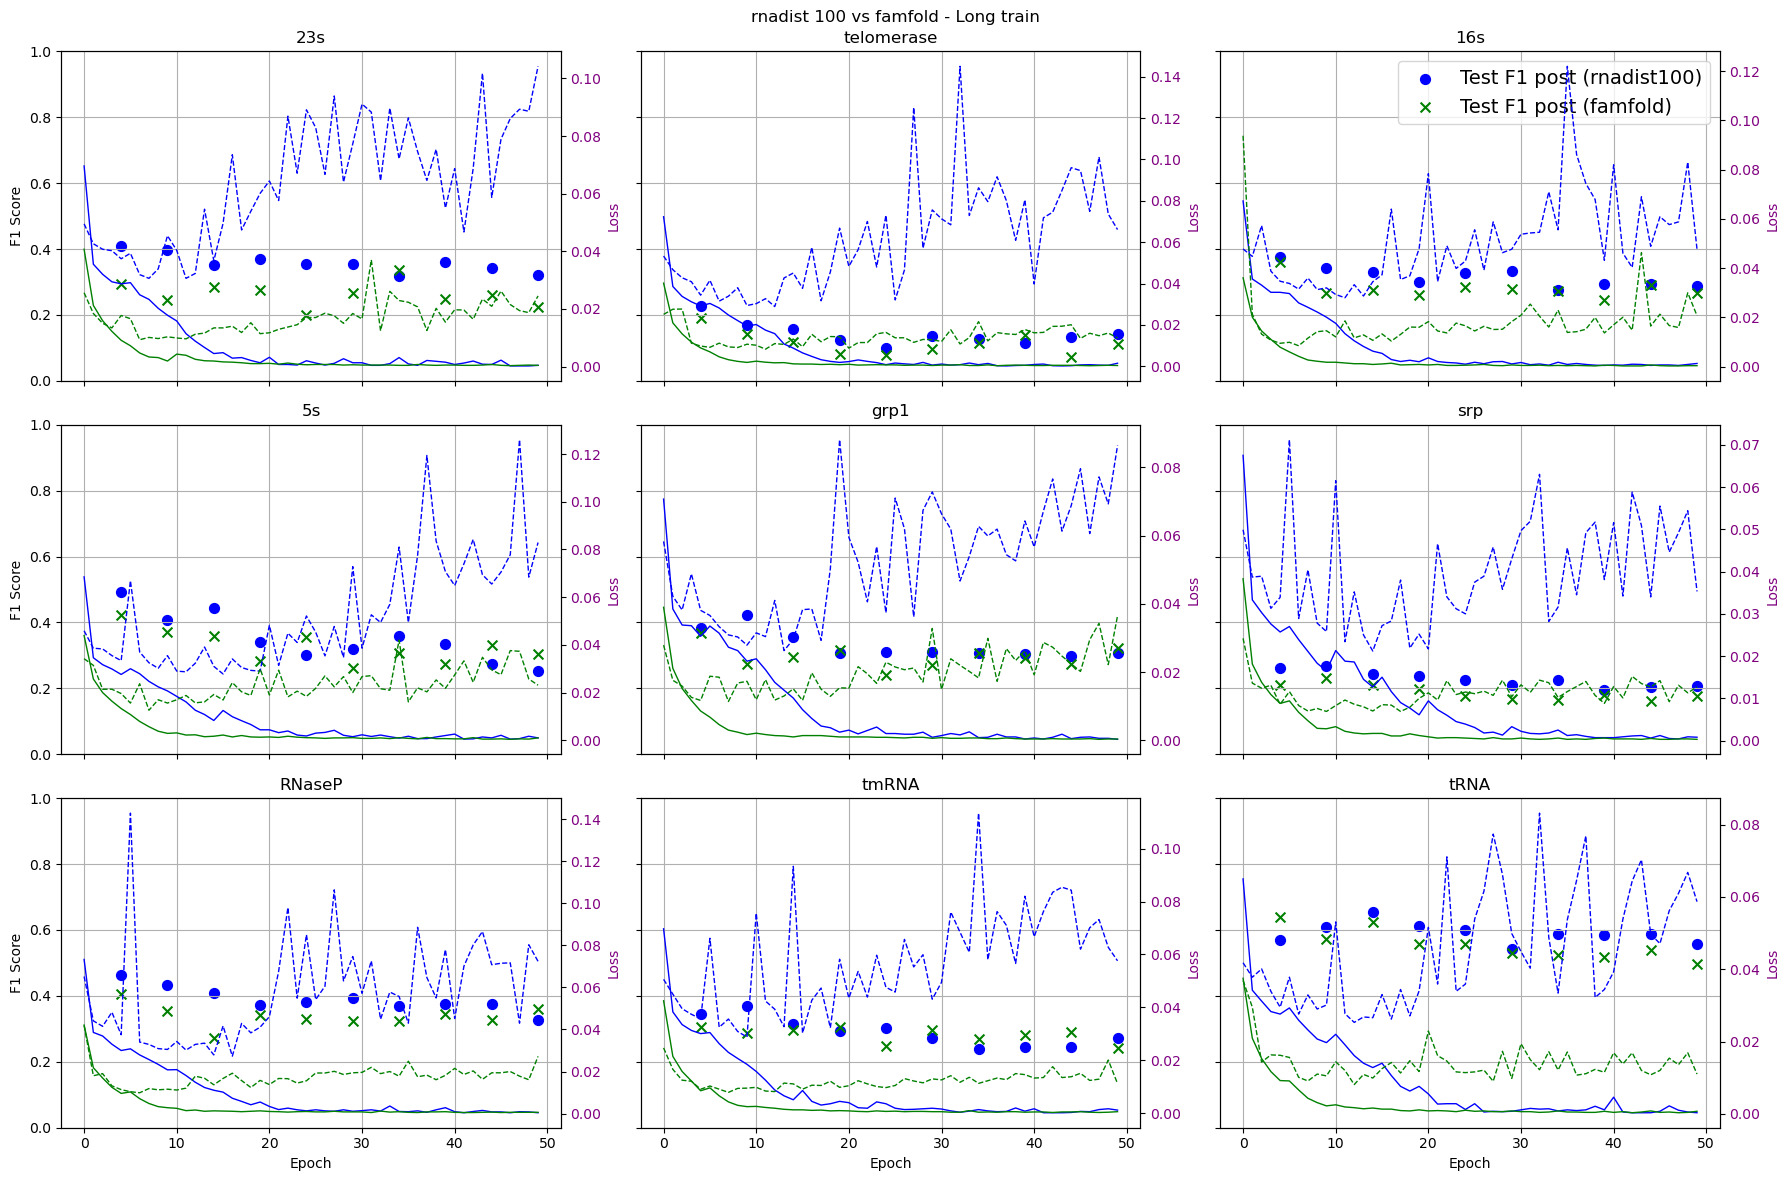

In [36]:
# leer ambos sets
dfs1 = read_dfs(rnadist100)
dfs2 = read_dfs(famfold)

n_fams = len(fams)
cols = 3
rows = (n_fams + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for ax, f in zip(axes, fams):
    df1 = dfs1[f]
    df2 = dfs2[f]


    # Test F1 post
    test_rows1 = df1['f1_post'].notna()
    test_rows2 = df2['f1_post'].notna()
    ax.scatter(df1.loc[test_rows1, 'epoch'], df1.loc[test_rows1, 'f1_post'],
               color='blue', s=50, label='Test F1 post (rnadist100)')
    ax.scatter(df2.loc[test_rows2, 'epoch'], df2.loc[test_rows2, 'f1_post'],
               color='green', s=50, marker='x', label='Test F1 post (famfold)')

    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.set_ylabel('Loss', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    # Train F1
    ax2.plot(df1['epoch'], df1['train_loss'], label='Train F1 (rnadist100)', color='blue', linewidth=1)
    ax2.plot(df1['epoch'], df1['valid_loss'], label='Train F1 (rnadist100)', color='blue', linewidth=1, linestyle='--')
    ax2.plot(df2['epoch'], df2['train_loss'], label='Train F1 (famfold)',    color='green', linewidth=1)
    ax2.plot(df2['epoch'], df2['valid_loss'], label='Train F1 (famfold)',    color='green', linewidth=1, linestyle='--')
     
for n in [6,7,8]:
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')

# legend solo en el primero
axes[2].legend(loc="upper right", fontsize=14)
 

fig.suptitle("rnadist 100 vs famfold - Long train")
fig.tight_layout()
plt.show()


/tmp/ipykernel_1261733/2216706229.py:57: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


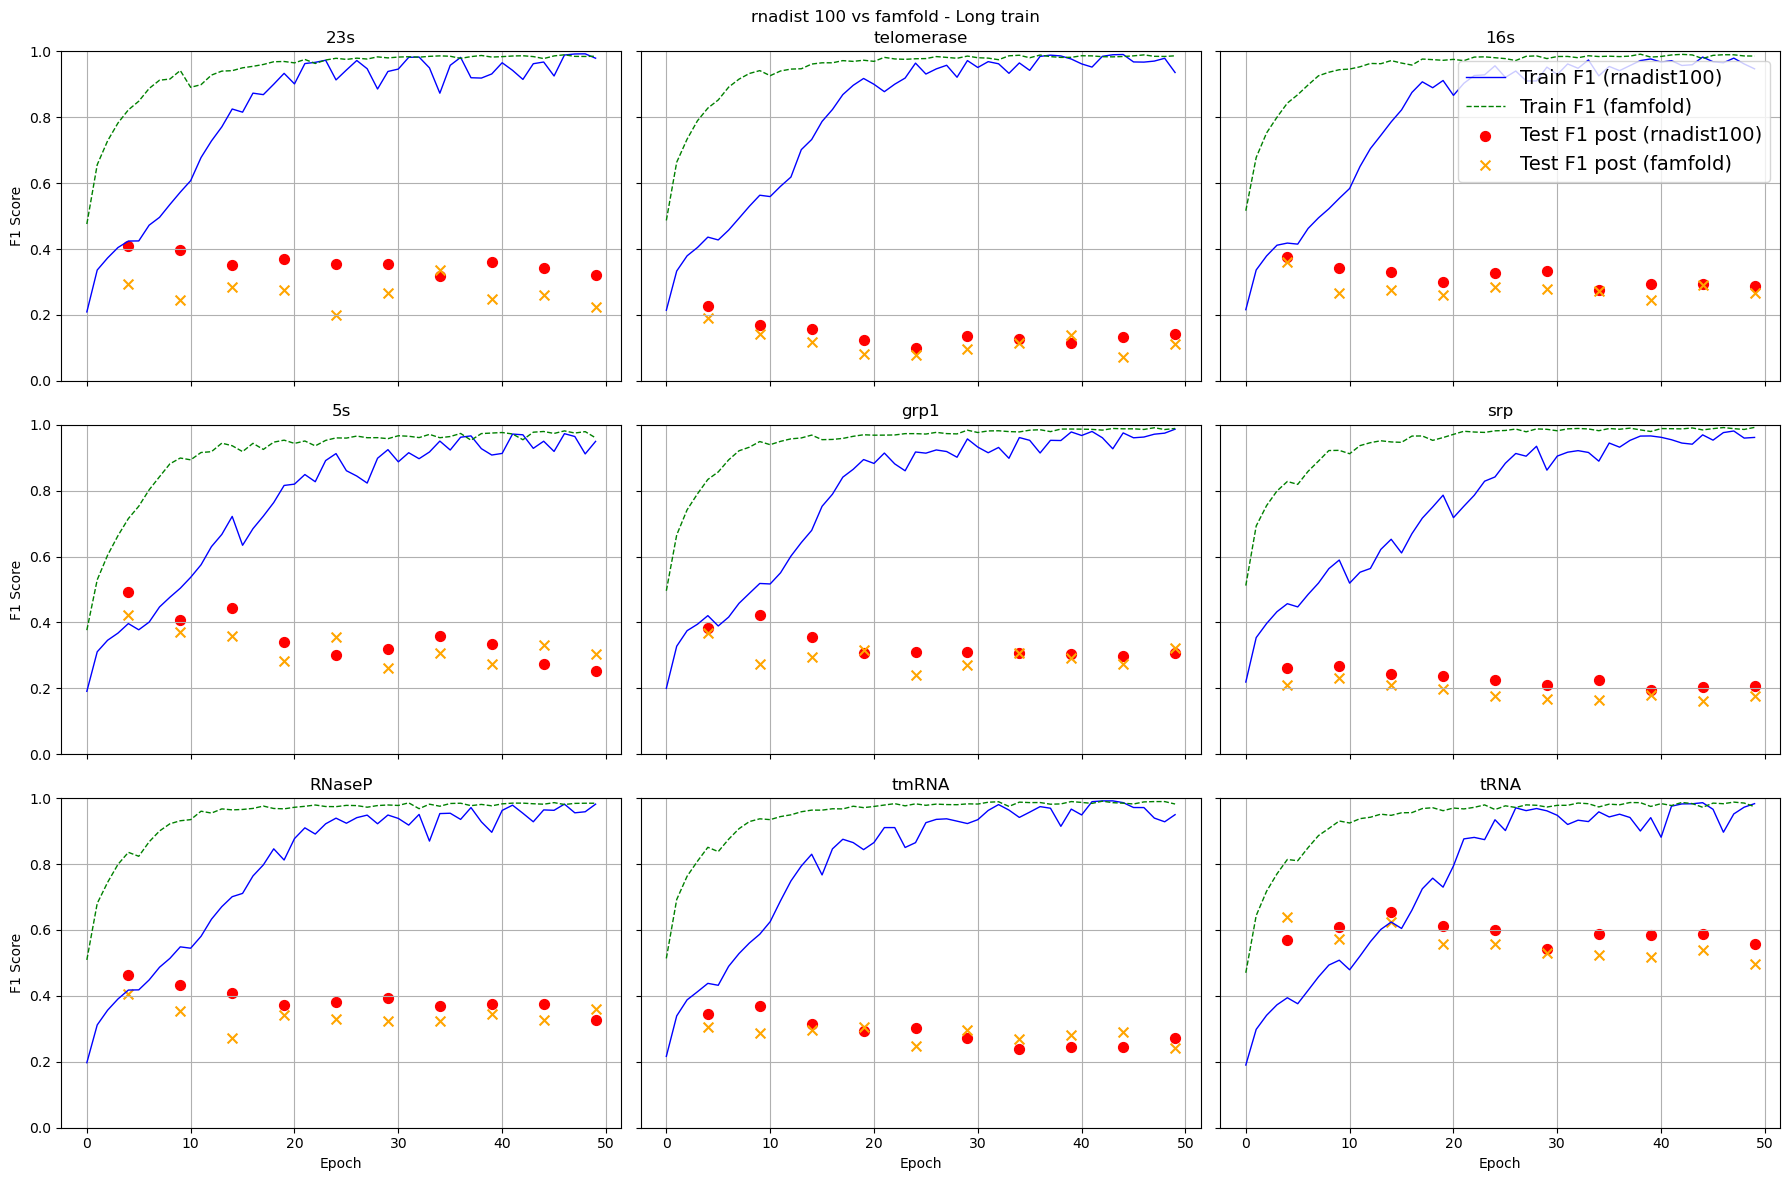

In [37]:

def filter_dfs(dfs, max_epoch=50):
    out = {}
    for fam, df in dfs.items():
        # por si 'epoch' viene como string en algún caso
        df2 = df.copy()
        df2['epoch'] = pd.to_numeric(df2['epoch'], errors='coerce')
        out[fam] = df2.loc[df2['epoch'] <= max_epoch].copy()
    return out

# leer ambos sets
dfs1 = read_dfs(rnadist100)
dfs2 = read_dfs(famfold)
dfs1_ = filter_dfs(dfs1, max_epoch=50)
dfs2_ = filter_dfs(dfs2, max_epoch=50)


n_fams = len(fams)
cols = 3
rows = (n_fams + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for ax, f in zip(axes, fams):
    df1 = dfs1_[f]
    df2 = dfs2_[f]

    # Train F1
    ax.plot(df1['epoch'], df1['train_f1'], label='Train F1 (rnadist100)', color='blue', linewidth=1)
    ax.plot(df2['epoch'], df2['train_f1'], label='Train F1 (famfold)',    color='green', linewidth=1, linestyle='--')

    # Test F1 post
    test_rows1 = df1['f1_post'].notna()
    test_rows2 = df2['f1_post'].notna()
    ax.scatter(df1.loc[test_rows1, 'epoch'], df1.loc[test_rows1, 'f1_post'],
               color='red', s=50, label='Test F1 post (rnadist100)')
    ax.scatter(df2.loc[test_rows2, 'epoch'], df2.loc[test_rows2, 'f1_post'],
               color='orange', s=50, marker='x', label='Test F1 post (famfold)')

    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(True)

for n in [6,7,8]:
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')

# legend solo en el primero
axes[2].legend(loc="upper right", fontsize=14)

# ocultar sobrantes
for ax in axes[n_fams:]:
    ax.set_visible(False)

fig.suptitle("rnadist 100 vs famfold - Long train")
fig.tight_layout()
plt.show()


In [38]:

def filter_dfs(dfs, max_epoch=50):
    out = {}
    for fam, df in dfs.items():
        # por si 'epoch' viene como string en algún caso
        df2 = df.copy()
        df2['epoch'] = pd.to_numeric(df2['epoch'], errors='coerce')
        out[fam] = df2.loc[df2['epoch'] <= max_epoch].copy()
    return out

# leer ambos sets
dfs1 = read_dfs(rnadist100)
dfs2 = read_dfs(famfold)
dfs1_ = filter_dfs(dfs1, max_epoch=50)
dfs2_ = filter_dfs(dfs2, max_epoch=50)
dfs3 = read_dfs(rnadist200)
dfs4 = read_dfs(rnadist400) 


In [39]:
dfs4['23s']

,epoch,train_f1,train_loss,valid_f1,valid_f1_post,valid_loss,f1,f1_post
0,0,0.3685,0.0460,0.4758,0.4809,0.0482,NaN,NaN
1,1,0.5027,0.0275,0.5245,0.6130,0.0271,NaN,NaN
2,2,0.5621,0.0229,0.6005,0.6564,0.0246,NaN,NaN
3,3,0.6061,0.0198,0.4755,0.6389,0.0297,NaN,NaN
4,4,0.6535,0.0163,0.6871,0.7367,0.0194,0.421,0.432
5,5,0.6842,0.0144,0.6434,0.6469,0.0412,NaN,NaN
6,6,0.7297,0.0115,0.6849,0.7615,0.0172,NaN,NaN
7,7,0.7852,0.0081,0.7401,0.7882,0.0174,NaN,NaN
8,8,0.8221,0.0063,0.5492,0.7218,0.0189,NaN,NaN
9,9,0.8641,0.0040,0.7737,0.7816,0.0273,0.270,0.273


In [47]:
import matplotlib.pyplot as plt

def plot_f1_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4)):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["rnadist100", "famfold"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(rnadist100)
    dfs2 = read_dfs(famfold)
    plot_f1_across_datasets([dfs1, dfs2], ["rnadist100", "famfold"], fams)
    """
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    base_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'gray']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            # Train F1
            ax.plot(df['epoch'], df['train_f1'], label=f'F1 ({name})',
                    color=color, linewidth=1, )

            # Test F1 post
            test_rows = df['f1_post'].notna()
            ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
                       color=color, s=50, marker='o' if i == 0 else 'x',
                       label=None)

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 1)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[2].legend(loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Comparación de F1 entre datasets", fontsize=16)
    fig.tight_layout()
    plt.show()


In [59]:
import matplotlib.pyplot as plt

def plot_loss_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4)):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["rnadist100", "famfold"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(rnadist100)
    dfs2 = read_dfs(famfold)
    plot_f1_across_datasets([dfs1, dfs2], ["rnadist100", "famfold"], fams)
    """
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    base_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'gray']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            # Train F1
            ax.plot(df['epoch'], df['train_loss'], label=f'train ({name})',
                    color=color, linewidth=1, )
            # Train F1
            ax.plot(df['epoch'], df['valid_loss'], label=None
                    ,color=color, linewidth=1,linestyle="--" )
 

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 0.1)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[2].legend(loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Comparación de train y valid loss entre datasets", fontsize=16)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_1261733/3513110289.py:70: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


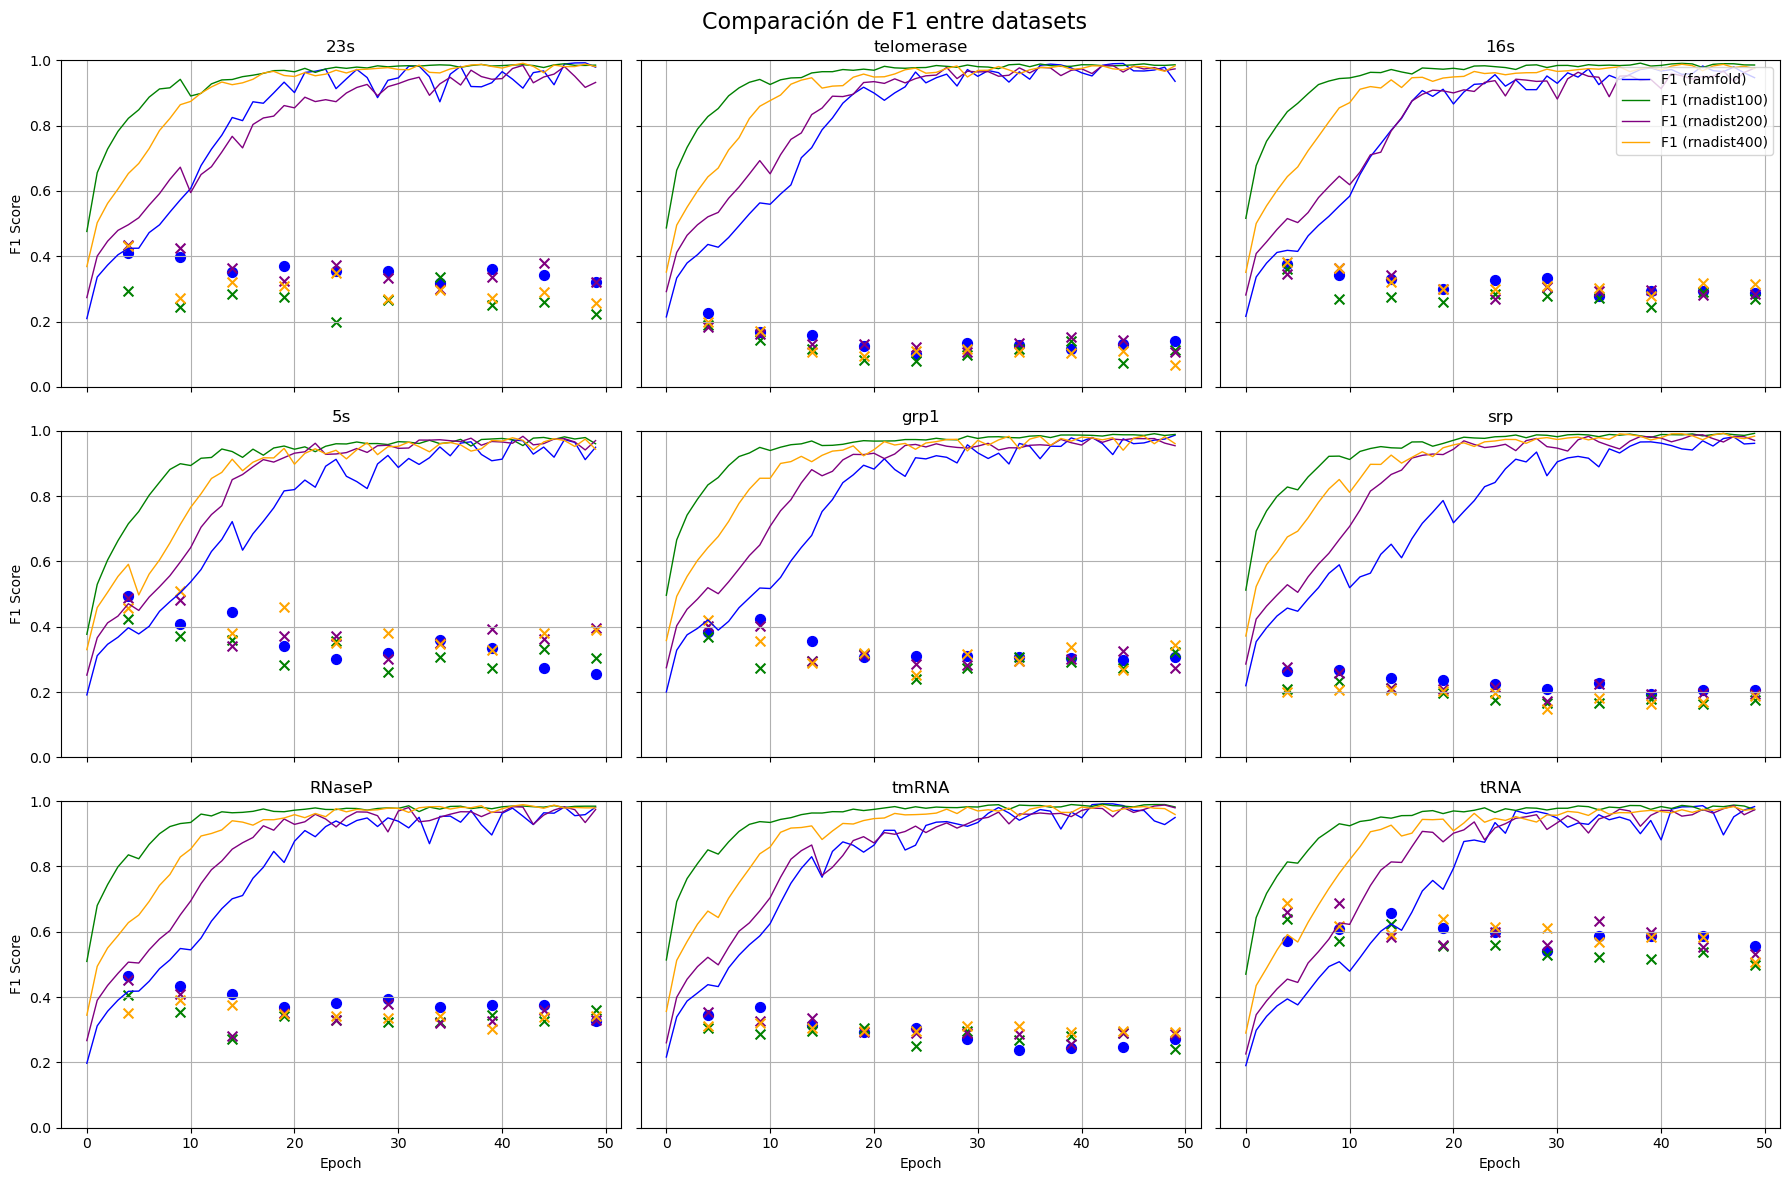

In [60]:

plot_f1_across_datasets(
    datasets=[dfs1_, dfs2_, dfs3, dfs4,],
    dataset_names=["famfold","rnadist100", "rnadist200", "rnadist400",],
    fams=fams
)


/tmp/ipykernel_1261733/575189701.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


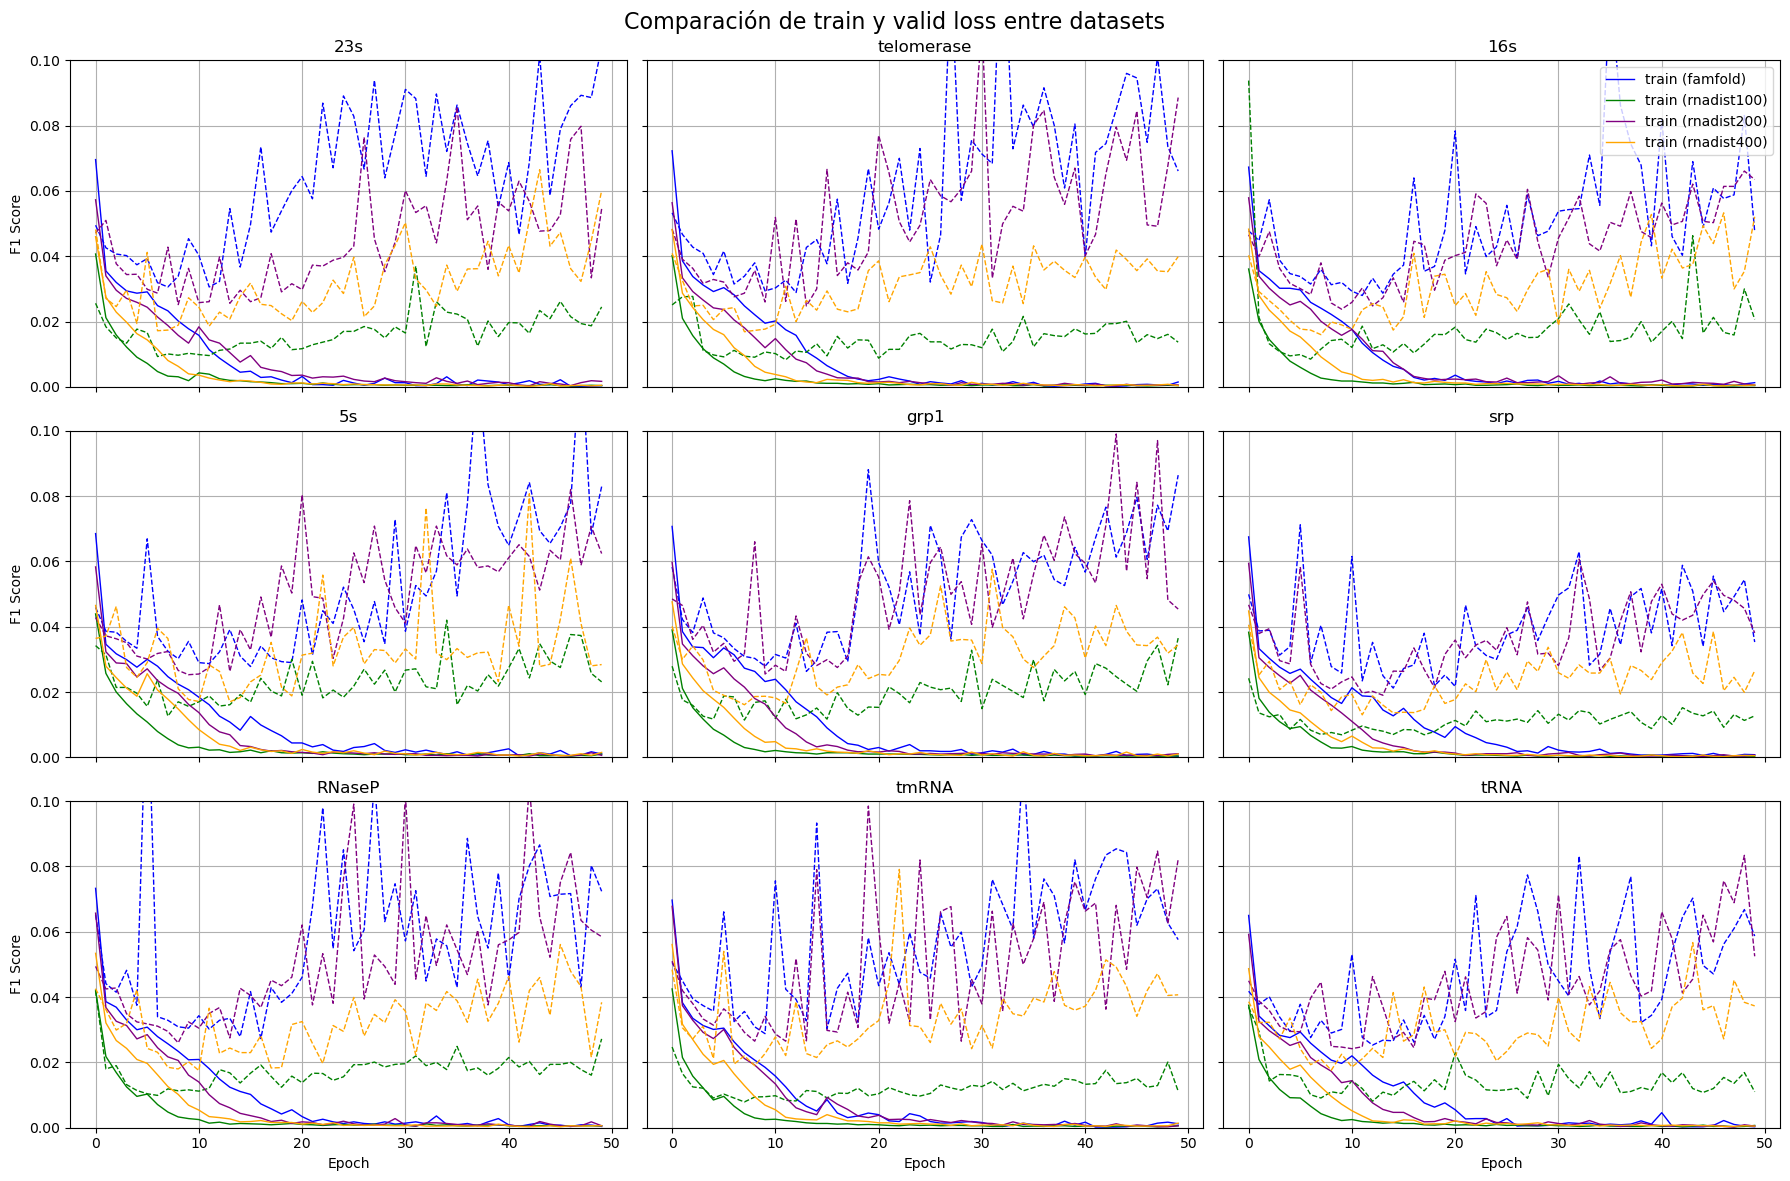

In [61]:

plot_loss_across_datasets(
    datasets=[dfs1_, dfs2_, dfs3, dfs4,],
    dataset_names=["famfold","rnadist100", "rnadist200", "rnadist400",],
    fams=fams
)
